In [1]:
# Cell 1 — Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn imported ✅")
print("All libraries loaded successfully! ✅")

numpy: 2.2.6
pandas: 2.3.3
sklearn imported ✅
All libraries loaded successfully! ✅


In [2]:
# Cell 2 — Load Dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Cell 3 — EDA (Exploring the Data)
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (891, 12)

Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


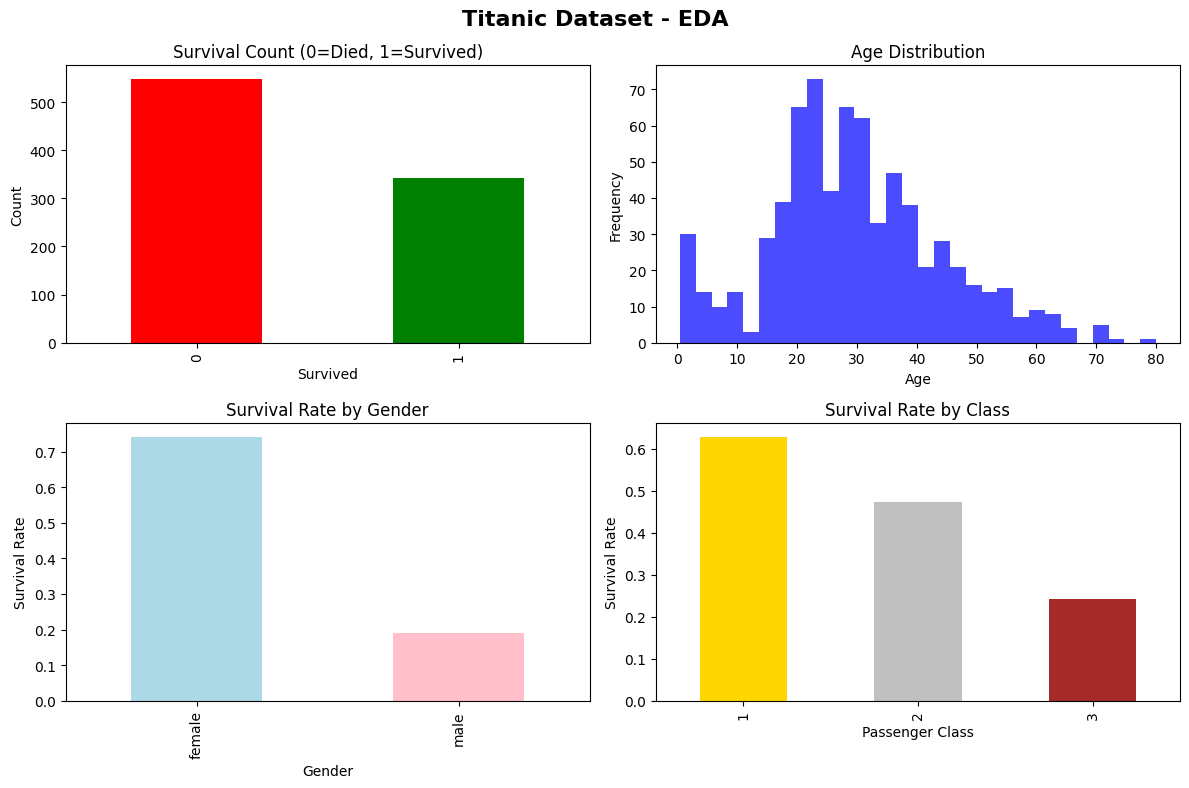

✅ EDA plots saved!


In [4]:
# Cell 4 — Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Titanic Dataset - EDA', fontsize=16, fontweight='bold')

# Plot 1 - Survival Count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['red','green'])
axes[0,0].set_title('Survival Count (0=Died, 1=Survived)')
axes[0,0].set_xlabel('Survived')
axes[0,0].set_ylabel('Count')

# Plot 2 - Age Distribution
df['Age'].dropna().plot(kind='hist', ax=axes[0,1], bins=30, color='blue', alpha=0.7)
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# Plot 3 - Survival by Gender
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1,0], color=['lightblue','pink'])
axes[1,0].set_title('Survival Rate by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Survival Rate')

# Plot 4 - Survival by Passenger Class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1,1], color=['gold','silver','brown'])
axes[1,1].set_title('Survival Rate by Class')
axes[1,1].set_xlabel('Passenger Class')
axes[1,1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('../data/processed/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

In [5]:
# Cell 5 — Feature Engineering
df2 = df.copy()

# Create new useful features
df2['FamilySize'] = df2['SibSp'] + df2['Parch'] + 1
df2['IsAlone'] = (df2['FamilySize'] == 1).astype(int)
df2['Title'] = df2['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df2['Title'] = df2['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                      'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df2['Title'] = df2['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

# Select features for training
features = ['Pclass','Sex','Age','Fare','Embarked','FamilySize','IsAlone','Title']
X = df2[features]
y = df2['Survived']

print("Features created successfully!")
print("\nNew features added: FamilySize, IsAlone, Title")
print("\nTitle value counts:")
print(df2['Title'].value_counts())
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("✅ Feature Engineering done!")

Features created successfully!

New features added: FamilySize, IsAlone, Title

Title value counts:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

X shape: (891, 8)
y shape: (891,)
✅ Feature Engineering done!


In [6]:
# Cell 6 — Build ML Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define numeric and categorical columns
num_cols = ['Age', 'Fare', 'FamilySize', 'IsAlone', 'Pclass']
cat_cols = ['Sex', 'Embarked', 'Title']

# Build preprocessing pipeline
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("✅ Pipeline built and data split done!")

X_train shape: (712, 8)
X_val shape: (179, 8)
✅ Pipeline built and data split done!


In [7]:
# Cell 7 — Train All Models
# Define all models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost":            XGBClassifier(n_estimators=300, learning_rate=0.05, eval_metric='logloss', random_state=42),
    "LightGBM":           LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=42),
    "CatBoost":           CatBoostClassifier(iterations=300, verbose=0, random_state=42),
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Build full pipeline
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    
    # Cross validation score
    cv_score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()
    
    # Train and validate
    pipe.fit(X_train, y_train)
    val_score = accuracy_score(y_val, pipe.predict(X_val))
    
    results[name] = {
        'CV Accuracy': round(cv_score, 4),
        'Val Accuracy': round(val_score, 4)
    }
    print(f"{name:25s} | CV: {cv_score:.4f} | Val: {val_score:.4f}")

# Show results table
print("\n--- Final Results ---")
results_df = pd.DataFrame(results).T.sort_values('Val Accuracy', ascending=False)
print(results_df)
print("\n✅ All models trained successfully!")

LogisticRegression        | CV: 0.8314 | Val: 0.8101
RandomForest              | CV: 0.7894 | Val: 0.8324
GradientBoosting          | CV: 0.8258 | Val: 0.8492
XGBoost                   | CV: 0.8048 | Val: 0.8268
LightGBM                  | CV: 0.8104 | Val: 0.8268
CatBoost                  | CV: 0.8314 | Val: 0.8380

--- Final Results ---
                    CV Accuracy  Val Accuracy
GradientBoosting         0.8258        0.8492
CatBoost                 0.8314        0.8380
RandomForest             0.7894        0.8324
XGBoost                  0.8048        0.8268
LightGBM                 0.8104        0.8268
LogisticRegression       0.8314        0.8101

✅ All models trained successfully!


In [8]:
# Cell 8 — Optuna Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    return cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()

print("🔍 Running Optuna tuning... (takes 2-3 mins)")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best CV Accuracy: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

🔍 Running Optuna tuning... (takes 2-3 mins)


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best CV Accuracy: 0.8356
Best Parameters: {'n_estimators': 492, 'max_depth': 3, 'learning_rate': 0.014137940890384178, 'subsample': 0.6826556734443129, 'min_samples_split': 9}


✅ Final Model Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


🔍 Generating SHAP explanation...


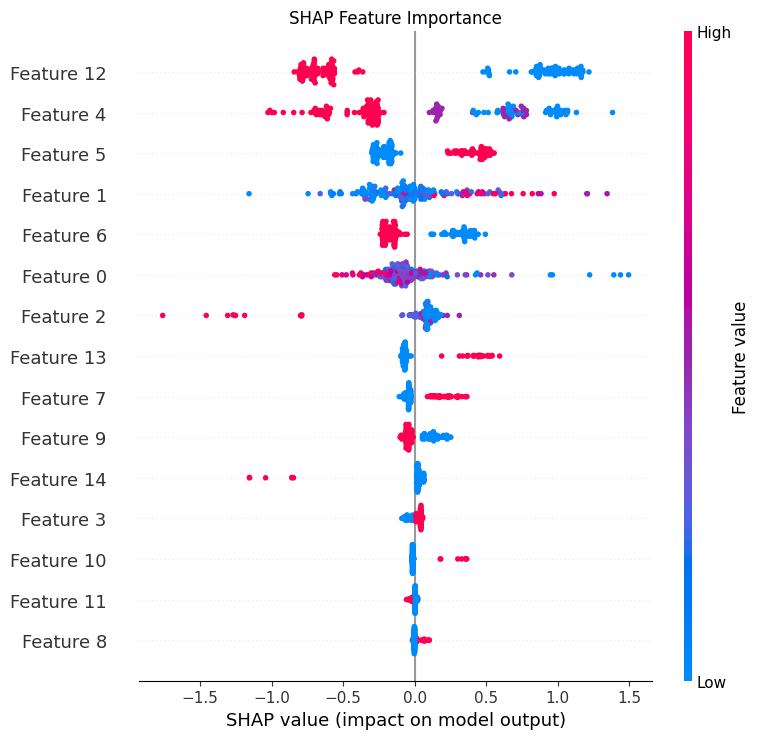

✅ SHAP plot saved!


In [9]:
# Cell 9 — Best Model + SHAP Explainability
import shap

# Train best model with tuned parameters
best_model = GradientBoostingClassifier(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    learning_rate=study.best_params['learning_rate'],
    subsample=study.best_params['subsample'],
    min_samples_split=study.best_params['min_samples_split'],
    random_state=42
)

best_pipe = Pipeline([('prep', preprocessor), ('model', best_model)])
best_pipe.fit(X_train, y_train)

# Final validation score
final_preds = best_pipe.predict(X_val)
final_acc = accuracy_score(y_val, final_preds)
print(f"✅ Final Model Accuracy: {final_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, final_preds, target_names=['Died','Survived']))

# SHAP — Feature Importance
print("\n🔍 Generating SHAP explanation...")
X_val_transformed = best_pipe['prep'].transform(X_val)
explainer = shap.TreeExplainer(best_pipe['model'])
shap_values = explainer.shap_values(X_val_transformed)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_transformed, show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved!")

In [10]:
# Cell 10 — Save the Best Model
import pickle
import os

# Create models/saved directory if not exists
os.makedirs('../models/saved', exist_ok=True)

# Save the pipeline (preprocessor + model together)
with open('../models/saved/best_titanic_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)

# Save results to CSV
results_df.to_csv('../data/processed/model_results.csv')

# Verify it works by loading it back
with open('../models/saved/best_titanic_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_val)
test_acc = accuracy_score(y_val, test_pred)

print(f"✅ Model saved successfully!")
print(f"✅ Loaded model accuracy: {test_acc:.4f}")
print(f"📁 Saved to: models/saved/best_titanic_model.pkl")
print(f"📁 Results saved to: data/processed/model_results.csv")

✅ Model saved successfully!
✅ Loaded model accuracy: 0.8045
📁 Saved to: models/saved/best_titanic_model.pkl
📁 Results saved to: data/processed/model_results.csv
